# Intro

The Goal is to see whether transfer learning from pretrained autoencoder model helps with classification or not. Intuitively autoencoder should help, however there is a possibility that autoencoder learns completely different features which hinder classification training. On the other hand side our autoencoder is going to be trained on 60K images, which maybe enough to defeat the potential disadvantage of transferred encoder from autoencoder architecture to classification problem.

Let's see which one is true.

1. We're going to import CIFAR data and create "full" (all 60K images) and "small" (2K images) dataloaders for images, dividing CIFAR into 2.
2. Later on we will create and train CNN-autoencoder which we will train on "full" dataloader.
3. Create new model with same encoder as in our Autoencoder model from 1. and FC linear layers instead of decoder layers. (i.e. we do classification model)
4. Train a "naive", i.e. not pretrained model to classify CIFAR10 - ON SMALL DATALOADER
5. Transfer the encoder weights and fine-tune - ON SMALL DATALOADER


# Libraries

In [4]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torchvision import transforms as T
from torch.utils.data import DataLoader, Subset

import copy

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

/tmp/ipython-input-1788710973.py:15: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

# Data

In [6]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([.5,.5,.5], [.5,.5,.5])
])

# import the data and simultaneously apply the transform
train_dataset = torchvision.datasets.CIFAR10(root='./data',
                                             train = True,
                                             download = True,
                                             transform = transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data',
                                            train = False,
                                            download = True,
                                            transform = transform)

batch_size = 32
full_train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = True)
full_test_dataloader = DataLoader(test_dataset, batch_size = 256)

100%|██████████| 170M/170M [00:13<00:00, 12.8MB/s]


Create smaller DataLoaders with only 2K images (used later)

In [7]:
small_train_dataset = Subset(train_dataset, range(2000))
small_test_dataset = Subset(test_dataset, range(2000))

small_train_dataloader = DataLoader(small_train_dataset, batch_size = batch_size, shuffle = True)
small_test_dataloader = DataLoader(small_test_dataset, batch_size = batch_size, shuffle = True)

# Viz


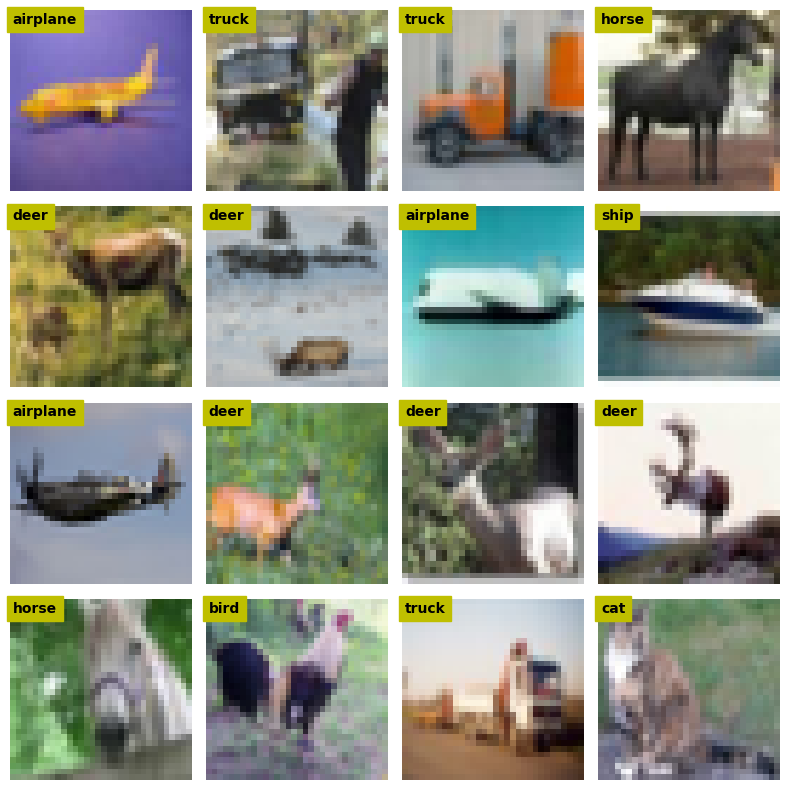

In [8]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import HTML

X, y = next(iter(small_train_dataloader))

fig, axs = plt.subplots(4, 4, figsize=(8, 8))

for (i, ax) in enumerate(axs.flatten()):
    pic = X.data[i].numpy().transpose((1, 2, 0))
    pic = pic / 2 + 0.5   # denormalizacja

    label = train_dataset.classes[y[i]]

    ax.imshow(pic, cmap='gray')
    ax.text(
        0, 0, label,
        ha='left', va='top',
        fontweight='bold',
        color='k',
        backgroundcolor='y'
    )
    ax.axis('off')

plt.tight_layout()

# === BASE64 INLINE RENDER ===
buf = io.BytesIO()
plt.savefig(buf, format="png", bbox_inches="tight", dpi=100)
plt.close(fig)

buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode("utf-8")

HTML(f"""
<img src="data:image/png;base64,{img_base64}" />
""")

# CNN-AE Model

In [9]:
def CreateAEModel(print_toggle = False):

  class CreateAENet(nn.Module):
    def __init__(self, print_toggle):
      super().__init__()

      # print toggle
      self.print = print_toggle

      ### -------- encoder layers --------- ###
      # first convolution layer
      self.enc_conv_1 = nn.Conv2d(3, 16, 4, padding = 1, stride = 2)
      # output size: (32+2*1-4)/2 + 1 = 16

      # second convolution layer
      self.enc_conv_2 = nn.Conv2d(16, 32, 4, padding = 1, stride = 2)
      # output size: (16+2*1-4)/2 + 1 = 8

      # third convolution layer
      self.enc_conv_3 = nn.Conv2d(32, 64, 4, padding = 1, stride = 2)
      # output size: (8+2*1-4)/2 + 1 = 4

      ### --------- decoder layers --------- ###
      # first convolution layer
      self.dec_conv_1 = nn.ConvTranspose2d(64, 32, 4, padding = 1, stride = 2)

      # second convolution layer
      self.dec_conv_2 = nn.ConvTranspose2d(32, 16, 4, padding = 1, stride = 2)

      # third convolution layer (output)
      self.dec_conv_3 = nn.ConvTranspose2d(16, 3, 4, padding = 1, stride = 2)


    def forward(self, x):

      if self.print: print(f'Input: {list(x.shape)}')



      # first encoder layer
      x = F.leaky_relu(self.enc_conv_1(x))
      if self.print: print(f'First encoder layer: {list(x.shape)}')

      # second encoder layer
      x = F.leaky_relu(self.enc_conv_2(x))
      if self.print: print(f'Second encoder layer: {list(x.shape)}')

      # third encoder layer
      x = F.leaky_relu(self.enc_conv_3(x))
      if self.print: print(f'Third encoder layer: {list(x.shape)}')




      # first decoder layer
      x = F.leaky_relu(self.dec_conv_1(x))
      if self.print: print(f'First decoder layer: {list(x.shape)}')

      # second decoder layer
      x = F.leaky_relu(self.dec_conv_2(x))
      if self.print: print(f'Second decoder layer: {list(x.shape)}')

      # second decoder layer
      x = F.leaky_relu(self.dec_conv_3(x))
      if self.print: print(f'Third decoder layer: {list(x.shape)}')



      return x

  # create the model instance
  net = CreateAENet(print_toggle)

  # loss function
  loss_fn = nn.MSELoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(), lr = .001, weight_decay = 1e-5)

  return net, loss_fn, optimizer

In [10]:
# test the model with one batch
temp_net, loss_fn, optimizer = CreateAEModel(True)

X, y = next(iter(small_train_dataloader))
y_hat = temp_net(X)

# check sie of output
print('\nOutput size:')
print(y_hat.shape)

# now let's compute the loss
loss = loss_fn(y_hat, X)
print(' ')
print('Loss:')
print(loss)

Input: [32, 3, 32, 32]
First encoder layer: [32, 16, 16, 16]
Second encoder layer: [32, 32, 8, 8]
Third encoder layer: [32, 64, 4, 4]
First decoder layer: [32, 32, 8, 8]
Second decoder layer: [32, 16, 16, 16]
Third decoder layer: [32, 3, 32, 32]

Output size:
torch.Size([32, 3, 32, 32])
 
Loss:
tensor(0.2567, grad_fn=<MseLossBackward0>)


## Train

In [11]:
def ModelAETrain(net,
                 train_dataloader,
                 val_dataloader,
                 verbose,
                 epochs):

    net.to(device)

    train_losses = torch.zeros(epochs)
    val_losses   = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()
        batch_loss = []

        # --- TRAIN ---
        for X, _ in train_dataloader:   # y ignored
            X = X.to(device)

            X_hat = net(X)
            loss = loss_fn(X_hat, X)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_loss.append(loss.item())

        train_losses[epoch] = torch.tensor(batch_loss).mean()

        # --- VALIDATION ---
        net.eval()
        with torch.no_grad():
            X, _ = next(iter(val_dataloader))
            X = X.to(device)
            X_hat = net(X)
            val_losses[epoch] = loss_fn(X_hat, X).item()

        if verbose:
            print(
                f"Epoch {epoch} | "
                f"Train loss: {train_losses[epoch]:.4f} | "
                f"Val loss: {val_losses[epoch]:.4f}"
            )

    return train_losses, val_losses, net

In [12]:
full_net, loss_fn, optimizer = CreateAEModel()

In [13]:
ae_full_train_losses, ae_full_val_losses, ae_full_net =\
 ModelAETrain(net = full_net,
              train_dataloader = full_train_dataloader,
              val_dataloader = full_test_dataloader,
              verbose = True,
              epochs = 10)

Epoch 0 | Train loss: 0.0616 | Val loss: 0.0389
Epoch 1 | Train loss: 0.0297 | Val loss: 0.0254
Epoch 2 | Train loss: 0.0232 | Val loss: 0.0222
Epoch 3 | Train loss: 0.0212 | Val loss: 0.0207
Epoch 4 | Train loss: 0.0199 | Val loss: 0.0195
Epoch 5 | Train loss: 0.0192 | Val loss: 0.0189
Epoch 6 | Train loss: 0.0186 | Val loss: 0.0183
Epoch 7 | Train loss: 0.0177 | Val loss: 0.0172
Epoch 8 | Train loss: 0.0168 | Val loss: 0.0164
Epoch 9 | Train loss: 0.0161 | Val loss: 0.0161


## Plots

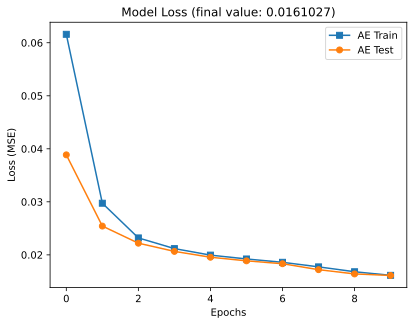

In [14]:
plt.plot(ae_full_train_losses, 's-', label = 'AE Train')
plt.plot(ae_full_val_losses, 'o-', label = 'AE Test')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Model Loss (final value: %g)'%ae_full_val_losses[-1])
plt.legend()
plt.show()

## Display Output


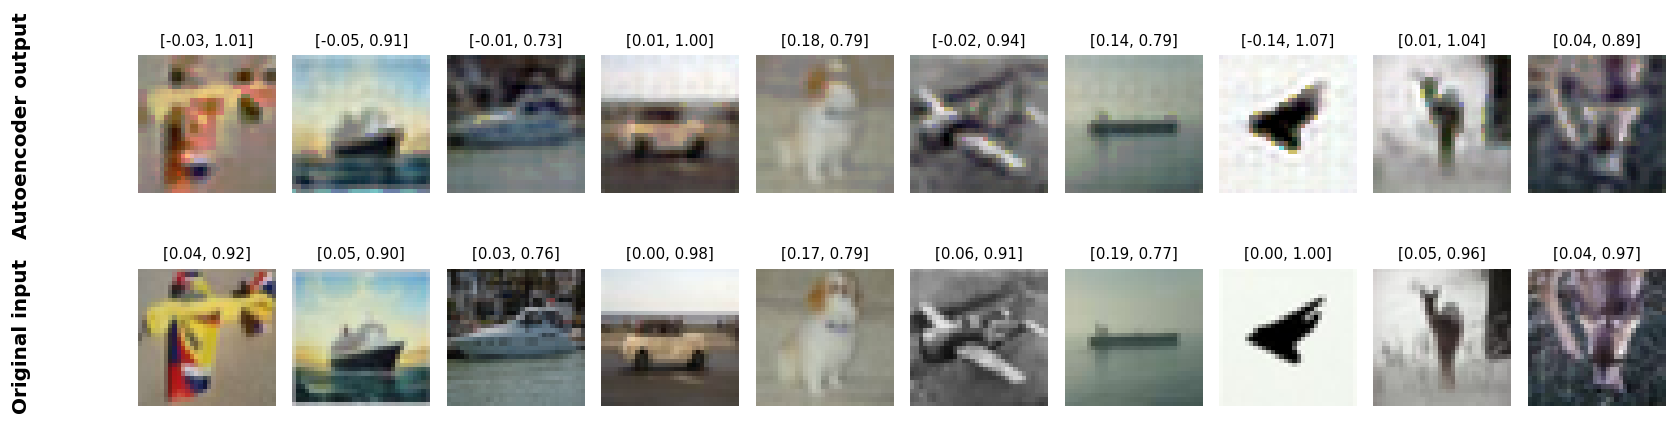

In [15]:
import matplotlib.pyplot as plt
import io
import base64
from IPython.display import HTML
import numpy as np
import torch

X, y = next(iter(small_test_dataloader))

ae_full_net.cpu()
ae_full_net.eval()

with torch.no_grad():
    y_hat = ae_full_net(X)

fig, axs = plt.subplots(2, 10, figsize=(14, 4))

# === ROW LABELS (FIGURE-LEVEL, NIE ZNIKAJĄ) ===
fig.text(0.005, 0.72, "Autoencoder output", va="center",
         rotation="vertical", fontsize=12, fontweight="bold")
fig.text(0.005, 0.28, "Original input", va="center",
         rotation="vertical", fontsize=12, fontweight="bold")

for i in range(10):
    # --- autoencoder output ---
    pic = y_hat[i].detach().numpy().transpose((1, 2, 0))
    pic = pic / 2 + 0.5
    axs[0, i].imshow(pic)
    axs[0, i].set_title(f'[{np.min(pic):.2f}, {np.max(pic):.2f}]', fontsize=9)
    axs[0, i].axis('off')

    # --- original input ---
    pic = X[i].detach().numpy().transpose((1, 2, 0))
    pic = pic / 2 + 0.5
    axs[1, i].imshow(pic)
    axs[1, i].set_title(f'[{np.min(pic):.2f}, {np.max(pic):.2f}]', fontsize=9)
    axs[1, i].axis('off')

plt.tight_layout()
plt.subplots_adjust(left=0.08)  # 👈 robi miejsce na etykiety

# === HTML / BASE64 ===
buf = io.BytesIO()
plt.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)

buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode("utf-8")

HTML(f"""
<div style="text-align:center">
  <img src="data:image/png;base64,{img_base64}" />
</div>
""")


# Naive-Class Model

In [23]:
def CreateNaiveClassModel(print_toggle = False):

  class CreateNaiveClassNet(nn.Module):
    def __init__(self, print_toggle):
      super().__init__()

      self.print = print_toggle

      ### --------- encoder layers --------- ###
      # first convolution layer
      self.enc_conv_1 = nn.Conv2d(3, 16, 4, padding = 1, stride = 2)
      # output size: (32+2*1-4)/2 + 1 = 16

      # second convolution layer
      self.enc_conv_2 = nn.Conv2d(16, 32, 4, padding = 1, stride = 2)
      # output size: (16+2*1-4)/2 + 1 = 8

      # third convolution layer
      self.enc_conv_3 = nn.Conv2d(32, 64, 4, padding = 1, stride = 2)
      # output size: (8+2*1-4)/2 + 1 = 4

      ### --------- linear layers ---------- ###
      self.fc1 = nn.Linear(4*4*64, 128)
      self.fc2 = nn.Linear(128,64)
      self.fc3 = nn.Linear(64,10)

    def forward(self, x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first encoder layer
      x = F.leaky_relu(self.enc_conv_1(x))
      if self.print: print(f'First encoder layer: {list(x.shape)}')

      # second encoder layer
      x = F.leaky_relu(self.enc_conv_2(x))
      if self.print: print(f'Second encoder layer: {list(x.shape)}')

      # third encoder layer
      x = F.leaky_relu(self.enc_conv_3(x))
      if self.print: print(f'Third encoder layer: {list(x.shape)}')



      # reshape to linear
      n_units = x.shape.numel()/x.shape[0]
      x = x.view(-1,int(n_units))
      if self.print: print(f'Post-convolution vectorized: {list(x.shape)}')

      # linear layers
      x = F.leaky_relu(self.fc1(x))
      if self.print: print(f'First linear layer: {list(x.shape)}')

      x = F.leaky_relu(self.fc2(x))
      if self.print: print(f'Second linear layer: {list(x.shape)}')

      x = F.leaky_relu(self.fc3(x))
      if self.print: print(f'Third linear layer: {list(x.shape)}')

      return x

  # create the model isntance
  net = CreateNaiveClassNet(print_toggle)

  # loss function
  loss_fn = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(), lr = .001)

  return net, loss_fn, optimizer

In [25]:
X.shape

torch.Size([32, 3, 32, 32])

In [26]:
y_hat.shape

torch.Size([32, 10])

In [28]:
y.shape

torch.Size([32])

In [31]:
# test the model with one batch
temp_net, loss_fn, optimizer = CreateNaiveClassModel(True)

X, y = next(iter(small_train_dataloader))
y_hat = temp_net(X)

# check sie of output
print('\nOutput size:')
print(y_hat.shape)

# now let's compute the loss
loss = loss_fn(y_hat, y)
print(' ')
print('Loss:')
print(loss)

pred = y_hat.argmax(dim=1)
acc = (pred == y).float().mean()
print(' ')
print("Acc:", acc.item())

Input: [32, 3, 32, 32]
First encoder layer: [32, 16, 16, 16]
Second encoder layer: [32, 32, 8, 8]
Third encoder layer: [32, 64, 4, 4]
Post-convolution vectorized: [32, 1024]
First linear layer: [32, 128]
Second linear layer: [32, 64]
Third linear layer: [32, 10]

Output size:
torch.Size([32, 10])
 
Loss:
tensor(2.3075, grad_fn=<NllLossBackward0>)
 
Acc: 0.09375


## Train

In [38]:
def ModelNaiveClassTrain(net,
                         train_dataloader,
                         val_dataloader,
                         loss_fn,
                         optimizer,
                         verbose,
                         print_inf,
                         epochs):

    net.to(device)

    train_losses = torch.zeros(epochs)
    val_losses   = torch.zeros(epochs)
    train_accs   = torch.zeros(epochs)
    val_accs     = torch.zeros(epochs)

    for epoch in range(epochs):
        net.train()
        batch_losses = []
        correct = 0
        total = 0

        # --- TRAIN ---
        for X, y in train_dataloader:
            X = X.to(device)
            y = y.to(device)

            logits = net(X)
            loss = loss_fn(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

        train_losses[epoch] = torch.tensor(batch_losses).mean()
        train_accs[epoch] = correct / total

        # --- VALIDATION ---
        net.eval()
        correct = 0
        total = 0
        val_batch_losses = []

        with torch.no_grad():
            for X, y in val_dataloader:
                X = X.to(device)
                y = y.to(device)

                logits = net(X)
                loss = loss_fn(logits, y)

                val_batch_losses.append(loss.item())

                preds = torch.argmax(logits, dim=1)
                correct += (preds == y).sum().item()
                total += y.size(0)

        val_losses[epoch] = torch.tensor(val_batch_losses).mean()
        val_accs[epoch] = correct / total

        if verbose:
            print(
                f"Epoch {epoch} | "
                f"Train loss: {train_losses[epoch]:.4f} | "
                f"Train acc: {train_accs[epoch]:.4f} | "
                f"Val loss: {val_losses[epoch]:.4f} | "
                f"Val acc: {val_accs[epoch]:.4f}"
            )

    return train_losses, val_losses, train_accs, val_accs, net

In [33]:
naive_class_net, loss_fn, optimizer = CreateNaiveClassModel(print_toggle = False)

In [40]:
naive_class_train_losses, naive_class_val_losses, \
naive_class_train_accs, naive_class_val_accs, \
naive_class_net = \
ModelNaiveClassTrain(net = naive_class_net,
                     train_dataloader = small_train_dataloader,
                     val_dataloader = small_test_dataloader,
                     loss_fn = loss_fn,
                     optimizer = optimizer,
                     verbose = True,
                     print_inf = False,
                     epochs = 15)

Epoch 0 | Train loss: 2.2666 | Train acc: 0.1705 | Val loss: 2.2078 | Val acc: 0.2090
Epoch 1 | Train loss: 2.0894 | Train acc: 0.2415 | Val loss: 2.0407 | Val acc: 0.2470
Epoch 2 | Train loss: 1.8593 | Train acc: 0.3275 | Val loss: 1.8483 | Val acc: 0.3340
Epoch 3 | Train loss: 1.7053 | Train acc: 0.3785 | Val loss: 1.7891 | Val acc: 0.3710
Epoch 4 | Train loss: 1.5938 | Train acc: 0.4240 | Val loss: 1.7705 | Val acc: 0.3765
Epoch 5 | Train loss: 1.5006 | Train acc: 0.4520 | Val loss: 1.6988 | Val acc: 0.4025
Epoch 6 | Train loss: 1.4258 | Train acc: 0.4910 | Val loss: 1.7916 | Val acc: 0.3660
Epoch 7 | Train loss: 1.3112 | Train acc: 0.5370 | Val loss: 1.7442 | Val acc: 0.3925
Epoch 8 | Train loss: 1.1781 | Train acc: 0.5775 | Val loss: 1.7409 | Val acc: 0.4260
Epoch 9 | Train loss: 1.0595 | Train acc: 0.6295 | Val loss: 1.7252 | Val acc: 0.4375
Epoch 10 | Train loss: 0.8972 | Train acc: 0.6880 | Val loss: 1.8726 | Val acc: 0.4110
Epoch 11 | Train loss: 0.7641 | Train acc: 0.7345 | V

## Plots

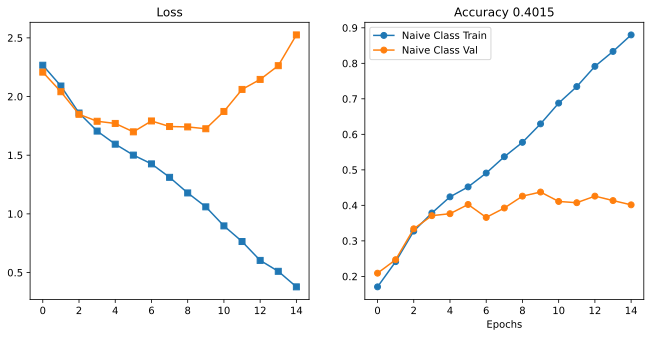

In [49]:
fig, ax = plt.subplots(1,2,figsize = (11,5))

ax[0].plot(naive_class_train_losses, 's-', label = 'Naive Class Train')
ax[0].plot(naive_class_val_losses, 's-', label = 'Naive Class Val')
ax[0].set_title('Loss')

ax[1].plot(naive_class_train_accs, 'o-', label = 'Naive Class Train')
ax[1].plot(naive_class_val_accs, 'o-', label = 'Naive Class Val')
ax[1].set_title('Accuracy %s'%round(naive_class_val_accs[-1].item(),4))

plt.xlabel('Epochs')
plt.legend()
plt.show()

Model is obviously overfitting and memorizing instead of generalizing.

# Informed-Class Model

## Transfer Weights

In [50]:
informed_class_net, loss_fn, optimizer = CreateNaiveClassModel(print_toggle = False)

In [52]:
for target, source in zip(informed_class_net.named_parameters(),
                          ae_full_net.named_parameters()):


  if 'enc' in target[0]:
    print('PRETRAIN: ' + target[0] + ' AENET: ' + source[0])

    # copy over the parameters
    target[1].data = copy.deepcopy(source[1].data)

    # and then freeze that layer
    # target[1].requires_grad = False

PRETRAIN: enc_conv_1.weight AENET: enc_conv_1.weight
PRETRAIN: enc_conv_1.bias AENET: enc_conv_1.bias
PRETRAIN: enc_conv_2.weight AENET: enc_conv_2.weight
PRETRAIN: enc_conv_2.bias AENET: enc_conv_2.bias
PRETRAIN: enc_conv_3.weight AENET: enc_conv_3.weight
PRETRAIN: enc_conv_3.bias AENET: enc_conv_3.bias


In [53]:
# double-check that they match
informed_class_net.cpu().enc_conv_1.weight[10] - ae_full_net.enc_conv_1.weight[10]

tensor([[[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]],

        [[0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.],
         [0., 0., 0., 0.]]], grad_fn=<SubBackward0>)

Weights match, i.e. transfer went well.

## Train

Let's now train pretrained model.

In [54]:
# train the pretrained model
informed_class_train_losses, informed_class_val_losses, \
informed_class_train_accs, informed_class_val_accs, \
informed_class_net = \
ModelNaiveClassTrain(net = informed_class_net,
                     train_dataloader = small_train_dataloader,
                     val_dataloader = small_test_dataloader,
                     loss_fn = loss_fn,
                     optimizer = optimizer,
                     verbose = True,
                     print_inf = False,
                     epochs = 15)

Epoch 0 | Train loss: 2.3445 | Train acc: 0.1185 | Val loss: 2.2968 | Val acc: 0.1700
Epoch 1 | Train loss: 2.2384 | Train acc: 0.1530 | Val loss: 2.1990 | Val acc: 0.1685
Epoch 2 | Train loss: 2.1779 | Train acc: 0.2105 | Val loss: 2.1795 | Val acc: 0.2385
Epoch 3 | Train loss: 2.1331 | Train acc: 0.2315 | Val loss: 2.1292 | Val acc: 0.2415
Epoch 4 | Train loss: 1.9966 | Train acc: 0.2930 | Val loss: 1.9938 | Val acc: 0.2905
Epoch 5 | Train loss: 1.8079 | Train acc: 0.3825 | Val loss: 1.9394 | Val acc: 0.3100
Epoch 6 | Train loss: 1.6003 | Train acc: 0.4550 | Val loss: 1.8230 | Val acc: 0.3900
Epoch 7 | Train loss: 1.3553 | Train acc: 0.5190 | Val loss: 1.7293 | Val acc: 0.4135
Epoch 8 | Train loss: 1.1342 | Train acc: 0.6125 | Val loss: 1.8353 | Val acc: 0.3875
Epoch 9 | Train loss: 0.9528 | Train acc: 0.6730 | Val loss: 1.7931 | Val acc: 0.4045
Epoch 10 | Train loss: 0.7290 | Train acc: 0.7655 | Val loss: 1.9830 | Val acc: 0.4090
Epoch 11 | Train loss: 0.5408 | Train acc: 0.8320 | V

## Plots

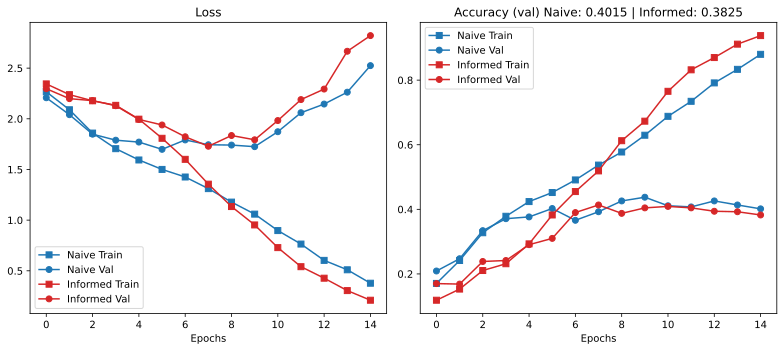

In [60]:
import matplotlib.pyplot as plt

naive_c = "tab:blue"
informed_c = "tab:red"

fig, ax = plt.subplots(1, 2, figsize=(11, 5))

# --- LOSS ---
ax[0].plot(naive_class_train_losses, marker='s', linestyle='-',
           color=naive_c, label='Naive Train')
ax[0].plot(naive_class_val_losses, marker='o', linestyle='-',
           color=naive_c, label='Naive Val')

ax[0].plot(informed_class_train_losses, marker='s', linestyle='-',
           color=informed_c, label='Informed Train')
ax[0].plot(informed_class_val_losses, marker='o', linestyle='-',
           color=informed_c, label='Informed Val')

ax[0].set_title('Loss')
ax[0].set_xlabel('Epochs')
ax[0].legend()

# --- ACCURACY ---
ax[1].plot(naive_class_train_accs, marker='s', linestyle='-',
           color=naive_c, label='Naive Train')
ax[1].plot(naive_class_val_accs, marker='o', linestyle='-',
           color=naive_c, label='Naive Val')

ax[1].plot(informed_class_train_accs, marker='s', linestyle='-',
           color=informed_c, label='Informed Train')
ax[1].plot(informed_class_val_accs, marker='o', linestyle='-',
           color=informed_c, label='Informed Val')

ax[1].set_title(
    "Accuracy (val) Naive: %.4f | Informed: %.4f"
    % (naive_class_val_accs[-1].item(), informed_class_val_accs[-1].item())
)
ax[1].set_xlabel('Epochs')
ax[1].legend()

plt.tight_layout()
plt.show()
